# TASK 1 - House Price Prediction

Saving train.csv to train.csv

Dataset loaded successfully!

First 5 rows:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     

/tmp/ipykernel_6472/2988365770.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = pd.to_numeric(data[col], errors='coerce')


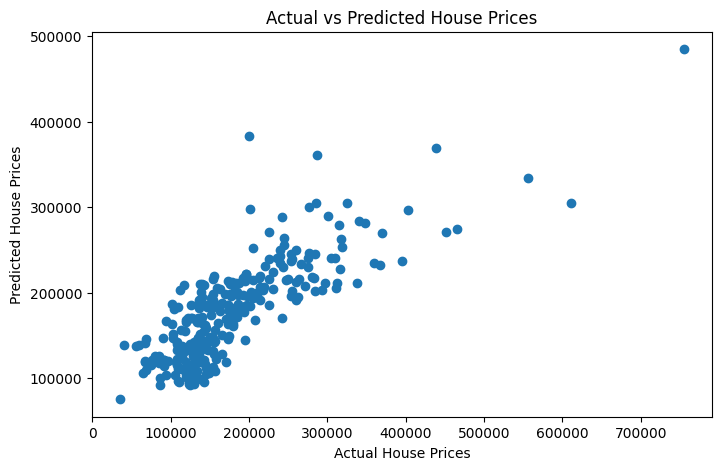


Example Prediction:
Predicted price for 2000 sqft, 3 bedrooms, 2 bathrooms: 240377.51479736282


In [ ]:
# Task 01: House Price Prediction using Linear Regression

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Upload ZIP or CSV file
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# If ZIP, extract it
if file_name.endswith(".zip"):
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall("house_dataset")

    print("ZIP extracted successfully!")
    print("Files inside ZIP:")

    for root, dirs, files_list in os.walk("house_dataset"):
        for file in files_list:
            print(os.path.join(root, file))

    # Automatically find CSV file
    csv_file = None
    for root, dirs, files_list in os.walk("house_dataset"):
        for file in files_list:
            if file.endswith(".csv"):
                csv_file = os.path.join(root, file)
                break

    if csv_file is None:
        raise Exception("No CSV file found inside ZIP.")

else:
    csv_file = file_name

# Load dataset
df = pd.read_csv(csv_file)

print("\nDataset loaded successfully!")
print("\nFirst 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

# Clean column names
df.columns = df.columns.str.strip()

# Try to automatically detect required columns
possible_area = ['area', 'sqft', 'squarefeet', 'square_feet', 'sqft_living', 'GrLivArea']
possible_bedrooms = ['bedrooms', 'bedroom', 'beds', 'Bedrooms', 'BedroomAbvGr']
possible_bathrooms = ['bathrooms', 'bathroom', 'baths', 'Bathrooms', 'FullBath']
possible_price = ['price', 'Price', 'SalePrice', 'median_house_value']

def find_column(possible_names):
    for col in df.columns:
        clean_col = col.replace(" ", "").replace("_", "").lower()
        for name in possible_names:
            clean_name = name.replace(" ", "").replace("_", "").lower()
            if clean_col == clean_name:
                return col
    return None

area_col = find_column(possible_area)
bedroom_col = find_column(possible_bedrooms)
bathroom_col = find_column(possible_bathrooms)
price_col = find_column(possible_price)

print("\nDetected Columns:")
print("Area column:", area_col)
print("Bedroom column:", bedroom_col)
print("Bathroom column:", bathroom_col)
print("Price column:", price_col)

if area_col is None or bedroom_col is None or bathroom_col is None or price_col is None:
    print("\nCould not detect columns automatically.")
    print("Available columns are:")
    print(df.columns)
    raise Exception("Rename your dataset columns or manually set area_col, bedroom_col, bathroom_col, and price_col.")

# Select required columns
data = df[[area_col, bedroom_col, bathroom_col, price_col]]

# Convert to numeric
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Remove missing values
data = data.dropna()

# Features and target
X = data[[area_col, bedroom_col, bathroom_col]]
y = data[price_col]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("\nModel Evaluation:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# Coefficients
print("\nModel Coefficients:")
print("Intercept:", model.intercept_)
print("Area coefficient:", model.coef_[0])
print("Bedroom coefficient:", model.coef_[1])
print("Bathroom coefficient:", model.coef_[2])

# Actual vs Predicted
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("\nActual vs Predicted:")
print(comparison.head(10))

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Predict custom house price
print("\nExample Prediction:")

new_house = pd.DataFrame({
    area_col: [2000],
    bedroom_col: [3],
    bathroom_col: [2]
})

predicted_price = model.predict(new_house)

print("Predicted price for 2000 sqft, 3 bedrooms, 2 bathrooms:", predicted_price[0])

# TASK 2 - Customer Segmentation using K-Means

Saving Mall_Customers.csv to Mall_Customers (1).csv
First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(

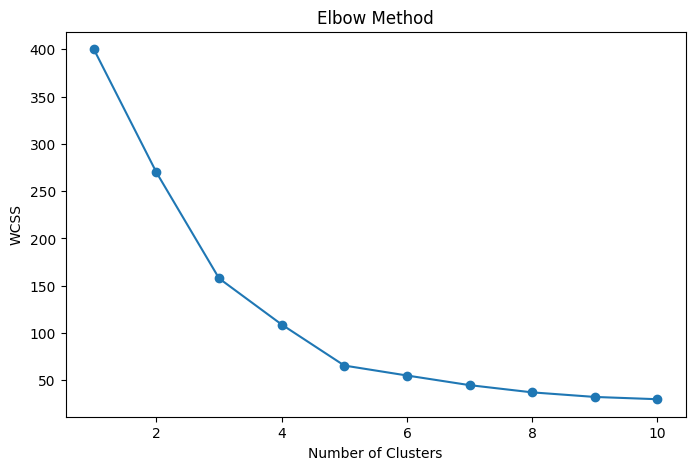


Dataset with Clusters:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


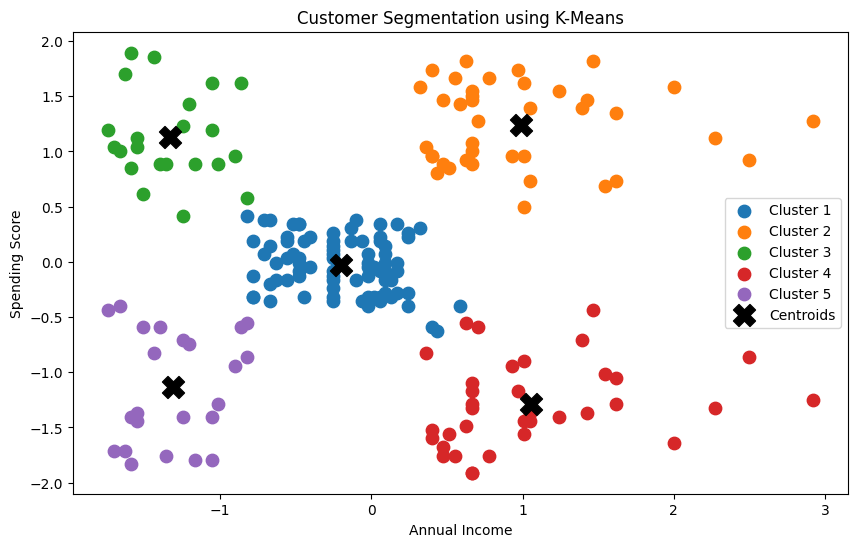


Cluster Analysis:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [ ]:
# K-Means Clustering on Mall Customer Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Upload dataset in Google Colab
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Display dataset
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Train K-Means model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column
df['Cluster'] = clusters

print("\nDataset with Clusters:")
print(df.head())

# Visualize clusters
plt.figure(figsize=(10, 6))

plt.scatter(X_scaled[clusters == 0, 0], X_scaled[clusters == 0, 1], s=80, label='Cluster 1')
plt.scatter(X_scaled[clusters == 1, 0], X_scaled[clusters == 1, 1], s=80, label='Cluster 2')
plt.scatter(X_scaled[clusters == 2, 0], X_scaled[clusters == 2, 1], s=80, label='Cluster 3')
plt.scatter(X_scaled[clusters == 3, 0], X_scaled[clusters == 3, 1], s=80, label='Cluster 4')
plt.scatter(X_scaled[clusters == 4, 0], X_scaled[clusters == 4, 1], s=80, label='Cluster 5')

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=250,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

# Cluster analysis
print("\nCluster Analysis:")
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

# TASK 3 - Cat vs Dog Classification using SVM

Saving cats_dogs_small.zip to cats_dogs_small (1).zip
Extraction completed!
Cats loaded: 1000
Dogs loaded: 1000
Total images: 2000
Feature shape: (2000, 4356)
Training started...
Training completed!
Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

         Cat       0.75      0.76      0.75       200
         Dog       0.76      0.74      0.75       200

    accuracy                           0.75       400
   macro avg       0.75      0.75      0.75       400
weighted avg       0.75      0.75      0.75       400



<Figure size 600x500 with 0 Axes>

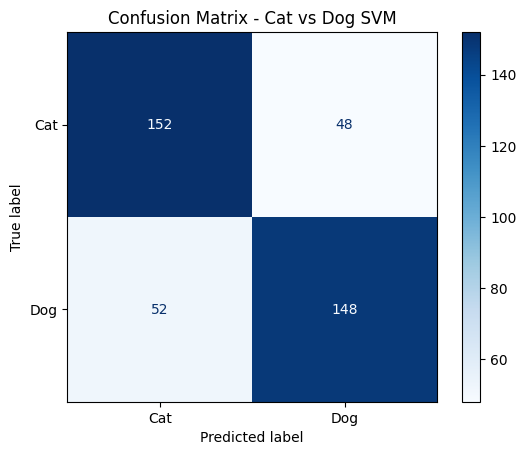

Upload one or more cat/dog images for testing:


Saving cat2.jpeg to cat2 (1).jpeg
Saving cat3.jpeg to cat3 (1).jpeg
Saving dog 3.jpeg to dog 3 (1).jpeg
Saving dog1.jpeg to dog1 (1).jpeg
cat2 (1).jpeg → Cat | Confidence: 85.97 %


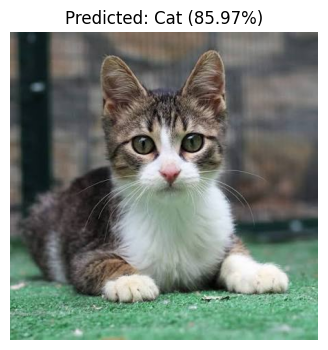

cat3 (1).jpeg → Cat | Confidence: 92.12 %


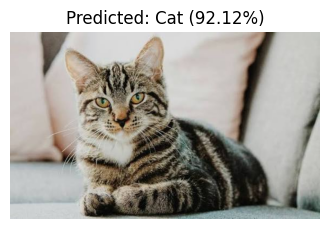

dog 3 (1).jpeg → Cat | Confidence: 62.25 %


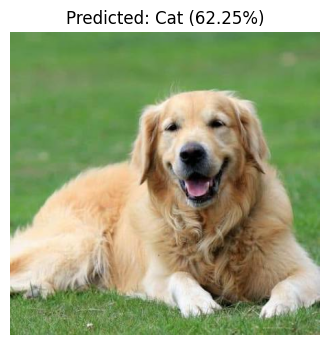

dog1 (1).jpeg → Cat | Confidence: 58.27 %


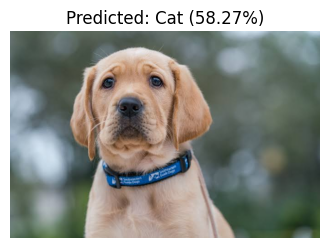

In [2]:
# Task 03: Cat vs Dog Classification using SVM
# Improved version with HOG features + Confusion Matrix Image + Multiple Image Testing

import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Upload train.zip
uploaded = files.upload()

# Extract zip
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Extraction completed!")

# Settings
img_size = 96
cat_limit = 1000
dog_limit = 1000

data = []
labels = []

cat_count = 0
dog_count = 0

# HOG feature extraction function
def extract_hog_features(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None

    img = cv2.resize(img, (img_size, img_size))
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    return features

# Load cat and dog images
# Iterate through all files in the extracted dataset directory and its subdirectories
for root, _, files_in_dir in os.walk("dataset"):
    for img_name in files_in_dir:
        img_path = os.path.join(root, img_name)
        lower_name = img_name.lower()

        try:
            features = extract_hog_features(img_path)

            if features is None:
                continue

            if lower_name.startswith("cat") and cat_count < cat_limit:
                data.append(features)
                labels.append(0)
                cat_count += 1

            elif lower_name.startswith("dog") and dog_count < dog_limit:
                data.append(features)
                labels.append(1)
                dog_count += 1

            if cat_count == cat_limit and dog_count == dog_limit:
                break  # Stop if limits are reached for both categories

        except:
            pass
    if cat_count == cat_limit and dog_count == dog_limit:
        break # Break from outer loop as well if limits are reached

# Convert to numpy arrays
X = np.array(data)
y = np.array(labels)

print("Cats loaded:", cat_count)
print("Dogs loaded:", dog_count)
print("Total images:", len(X))
print("Feature shape:", X.shape)

if len(X) == 0:
    raise Exception("No images loaded. Check file names. They should start with cat or dog.")

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train improved SVM model
model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True
)

print("Training started...")
model.fit(X_train, y_train)
print("Training completed!")

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Cat", "Dog"]))

# Confusion matrix as image
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Cat vs Dog SVM")
plt.show()

# Test multiple images
print("Upload one or more cat/dog images for testing:")
uploaded_test = files.upload()

for test_img_name in uploaded_test.keys():

    test_img = cv2.imread(test_img_name)

    if test_img is None:
        print(test_img_name, "could not be read.")
        continue

    test_features = extract_hog_features(test_img_name)

    test_features = np.array([test_features])

    prediction = model.predict(test_features)
    probability = model.predict_proba(test_features)

    if prediction[0] == 0:
        result = "Cat"
    else:
        result = "Dog"

    confidence = np.max(probability) * 100

    print(test_img_name, "→", result, "| Confidence:", round(confidence, 2), "%")

    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
    plt.title("Predicted: " + result + " (" + str(round(confidence, 2)) + "%)")
    plt.axis("off")
    plt.show()